In [1]:
import os
import gc
from PIL import Image
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from torchvision import transforms
import torchvision.models as models

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [3]:
class ArtifactDataset(Dataset):
    def __init__(self, root_dir, file_names, labels, transform=None):
        self.root_dir = root_dir
        self.file_names = file_names
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, index):
        img_path = os.path.join(self.root_dir, self.file_names[index])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.labels[index]

    def show(self, index):
        img_tensor, label = self[index]
        img_array = img_tensor.numpy().transpose((1, 2, 0))
        img_array = np.clip(img_array, 0, 1)

        plt.imshow(img_array)
        plt.title(f"Label: {label}")
        plt.axis("off")
        plt.show()

In [32]:
train_transforms = transforms.Compose([
    transforms.Resize((512, 512)),

    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(contrast=(0.8, 1.5), brightness=(0.8, 1.2)),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),

    transforms.CenterCrop(224),
    transforms.ToTensor(),

])

val_transforms = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

In [5]:
class ArtifactEncoder(nn.Module):
    def __init__(self, latent_size):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.GELU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
        )
        self.flatten = nn.Flatten()
        self.in_latent = nn.Linear(128 * 14 * 14, latent_size)

    def forward(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        x = self.in_latent(x)

        return x

In [6]:
class ArtifactDecoder(nn.Module):
    def __init__(self, latent_size):
        super().__init__()

        self.out_latent = nn.Linear(latent_size, 128 * 14 * 14)
        self.unflatten = nn.Unflatten(1, (128, 14, 14))
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.GELU(),

            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.out_latent(x)
        x = self.unflatten(x)
        x = self.decoder(x)

        return x

In [7]:
class ArtifactAutoencoder(nn.Module):
    def __init__(self, latent_size):
        super().__init__()

        self.encoder = ArtifactEncoder(latent_size)
        self.decoder = ArtifactDecoder(latent_size)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [8]:
class PerceptualLoss(nn.Module):
    def __init__(self, reduction='mean'):
        super().__init__()
        self.eval()
        self.reduction = reduction
        vgg_features = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features

        self.slice1 = torch.nn.Sequential()
        self.slice2 = torch.nn.Sequential()
        self.slice3 = torch.nn.Sequential()

        for x in range(4):   self.slice1.add_module(str(x), vgg_features[x])
        for x in range(4, 9):  self.slice2.add_module(str(x), vgg_features[x])
        for x in range(9, 16): self.slice3.add_module(str(x), vgg_features[x])

        for param in self.parameters():
            param.requires_grad = False

        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, reconstructed, original):
        orig_norm = (original - self.mean) / self.std
        recon_norm = (reconstructed - self.mean) / self.std

        with torch.no_grad():
            orig_f1 = self.slice1(orig_norm)
            orig_f2 = self.slice2(orig_f1)
            orig_f3 = self.slice3(orig_f2)

        recon_f1 = self.slice1(recon_norm)
        recon_f2 = self.slice2(recon_f1)
        recon_f3 = self.slice3(recon_f2)

        loss_f1 = F.mse_loss(orig_f1, recon_f1, reduction='none')
        loss_f2 = F.mse_loss(orig_f2, recon_f2, reduction='none')
        loss_f3 = F.mse_loss(orig_f3, recon_f3, reduction='none')

        if self.reduction == 'mean':
            return loss_f1.mean() + loss_f2.mean() + loss_f3.mean()

        target_size = original.shape[2:]

        map_f1 = F.interpolate(loss_f1, size=target_size, mode='bilinear', align_corners=False)
        map_f2 = F.interpolate(loss_f2, size=target_size, mode='bilinear', align_corners=False)
        map_f3 = F.interpolate(loss_f3, size=target_size, mode='bilinear', align_corners=False)

        total_error_map = map_f1.mean(dim=1, keepdim=True) + \
                          map_f2.mean(dim=1, keepdim=True) + \
                          map_f3.mean(dim=1, keepdim=True)

        return total_error_map

In [37]:
def train_one_epoch(model, loader, criterion, optimizer, alpha=1.0, beta=100.0):
    model.train()
    epoch_loss = 0.0
    epoch_vgg = 0.0
    epoch_mse = 0.0

    for inputs, _ in tqdm(loader, desc="Training", leave=False):
        optimizer.zero_grad()

        inputs = inputs.to(device)
        outputs = model(inputs)

        if isinstance(criterion, tuple):
            loss_vgg = criterion[0](outputs, inputs)
            loss_mse = criterion[1](outputs, inputs)
            loss = (alpha * loss_vgg) + (beta * loss_mse)

            epoch_vgg += loss_vgg.item()
            epoch_mse += loss_mse.item()
        else:
            loss = criterion(outputs, inputs)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    avg_vgg = epoch_vgg / len(loader) if isinstance(criterion, tuple) else 0.0
    avg_mse = epoch_mse / len(loader) if isinstance(criterion, tuple) else 0.0

    return avg_loss, avg_vgg, avg_mse

In [38]:
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, alpha=1.0, beta=100.0):
    model.eval()
    epoch_loss = 0.0
    epoch_vgg = 0.0
    epoch_mse = 0.0

    with torch.no_grad():
        for inputs, _ in tqdm(loader, desc="Validating", leave=False):
            inputs = inputs.to(device)
            outputs = model(inputs)

            if isinstance(criterion, tuple):
                loss_vgg = criterion[0](outputs, inputs)
                loss_mse = criterion[1](outputs, inputs)
                loss = (alpha * loss_vgg) + (beta * loss_mse)

                epoch_vgg += loss_vgg.item()
                epoch_mse += loss_mse.item()
            else:
                loss = criterion(outputs, inputs)

            epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    avg_vgg = epoch_vgg / len(loader) if isinstance(criterion, tuple) else 0.0
    avg_mse = epoch_mse / len(loader) if isinstance(criterion, tuple) else 0.0

    return avg_loss, avg_vgg, avg_mse

<h4>Training</h4>

In [39]:
train_dir = "data/train"
all_files = os.listdir(train_dir)

zeros_files = [(0, f) for f in all_files if f.split("_")[-1][0] == '0']
ones_files = [(1, f) for f in all_files if f.split("_")[-1][0] == '1']

np.random.seed(42)
np.random.shuffle(ones_files)

num_val_ones = len(zeros_files)

train_val_files = ones_files[num_val_ones:]
train_val_labels, train_val_file_names = zip(*train_val_files)
train_file_names, val_file_names, train_labels, val_labels = train_test_split(
    train_val_file_names, train_val_labels, test_size=0.2, random_state=42
)

trh_files = zeros_files + ones_files[:num_val_ones]
trh_labels, trh_file_names = zip(*trh_files)

train_set = ArtifactDataset(train_dir, train_file_names, train_labels, train_transforms)
val_set = ArtifactDataset(train_dir, val_file_names, val_labels, val_transforms)
trh_set = ArtifactDataset(train_dir, trh_file_names, trh_labels, val_transforms)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
trh_loader = DataLoader(trh_set, batch_size=64, shuffle=False)

In [40]:
latent_size = 128
criterion_type = "hybrid"

load_model_name = f"models/artifact_eliminator_hybrid_{latent_size}.pth"
save_model_name = f"models/artifact_eliminator_{criterion_type}_{latent_size}.pth"

model = ArtifactAutoencoder(latent_size=latent_size).to(device)
model.load_state_dict(torch.load(load_model_name, map_location=device))

if criterion_type == "vgg":
    criterion = PerceptualLoss(reduction='mean').to(device)
elif criterion_type == "mse":
    criterion = nn.MSELoss(reduction='mean').to(device)
elif criterion_type == "hybrid":
    criterion_vgg = PerceptualLoss(reduction='mean').to(device)
    criterion_mse = nn.MSELoss(reduction='mean').to(device)
    criterion = (criterion_vgg, criterion_mse)

optimizer = Adam(model.parameters(), lr=1e-3)

C:\Users\ACER\AppData\Local\Temp\ipykernel_10760\1593537162.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(load_model_name, map_locatio

Training:   0%|          | 0/18 [00:00<?, ?it/s]

Validating:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 100/100
    Train Total: 28.2987 (VGG: 25.7589, MSE: 0.0254)
    Val Total:   25.5240 (VGG: 23.3123, MSE: 0.0221)
    Model saved



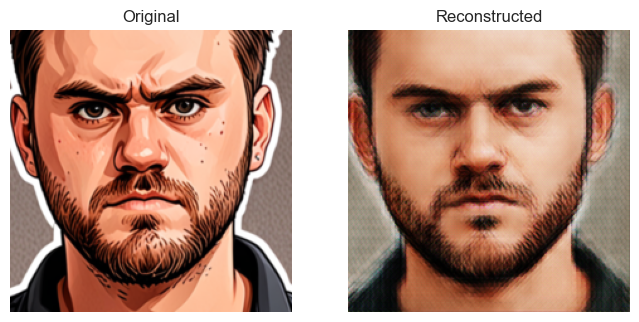

In [41]:
num_epochs = 100
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

writer = SummaryWriter('runs/AE')

sample_input, _ = next(iter(val_loader))
sample_input = sample_input[0:1].to(device)

for epoch in range(num_epochs):
    train_loss, train_vgg, train_mse = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_vgg, val_mse = validate_one_epoch(model, val_loader, criterion)

    writer.add_scalars('Loss/Total', {'train': train_loss, 'val': val_loss}, epoch + 1)

    if criterion_type == "hybrid":
        writer.add_scalars('Loss/VGG_Component', {'train': train_vgg, 'val': val_vgg}, epoch + 1)
        writer.add_scalars('Loss/MSE_Component', {'train': train_mse, 'val': val_mse}, epoch + 1)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    if criterion_type == "hybrid":
        print(f"    Train Total: {train_loss:.4f} (VGG: {train_vgg:.4f}, MSE: {train_mse:.4f})")
        print(f"    Val Total:   {val_loss:.4f} (VGG: {val_vgg:.4f}, MSE: {val_mse:.4f})")
    else:
        print(f"    Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), save_model_name)
        print(f"    Model saved")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    print()

    model.eval()
    with torch.no_grad():
        sample_output = model(sample_input)

        img_original = sample_input[0].cpu().numpy().transpose((1, 2, 0))
        img_reconstructed = sample_output[0].cpu().numpy().transpose((1, 2, 0))
        img_original = np.clip(img_original, 0, 1)
        img_reconstructed = np.clip(img_reconstructed, 0, 1)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))

        axes[0].imshow(img_original)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(img_reconstructed)
        axes[1].set_title(f"Reconstructed")
        axes[1].axis("off")

        plt.show()
        plt.close(fig)

writer.close()

<h4>Threshold selection</h4>

In [14]:
@torch.no_grad()
def get_anomaly_scores(model, loader, criterion, top_k_percent):
    model.eval()
    all_scores = []

    for inputs, _ in tqdm(loader, desc="Validating", leave=False):
        inputs = inputs.to(device)
        outputs = model(inputs)

        pixel_losses = criterion(outputs, inputs)
        batch_size = pixel_losses.size(0)
        flat_losses = pixel_losses.view(batch_size, -1)

        k_pixels = int(flat_losses.size(1) * top_k_percent)
        topk_values, _ = torch.topk(flat_losses, k_pixels, dim=1)

        scores = topk_values.mean(dim=1)

        all_scores.extend(scores.cpu().numpy())

    return all_scores

In [15]:
def get_best_threshold(scores, labels, num_steps=200):
    thresholds = np.linspace(min(scores), max(scores), num_steps)

    best_f1 = 0.0
    best_threshold = 0.0
    conf_matrix = None

    for threshold in thresholds:
        preds = (scores <= threshold).astype(int)
        f1 = f1_score(labels, preds, average='macro')

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            conf_matrix = confusion_matrix(labels, preds)

    return best_threshold, best_f1, conf_matrix

In [86]:
latent_size = 128
model_type = "hybrid"
criterion_type = "mse"

top_k_candidates = [0.02, 0.03, 0.05, 0.07, 0.1]

model_path = f"models/artifact_eliminator_{model_type}_{latent_size}.pth"
model = ArtifactAutoencoder(latent_size).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))

if criterion_type == "vgg":
    criterion = PerceptualLoss(reduction='none').to(device)
elif criterion_type == "mse":
    criterion = nn.MSELoss(reduction='none').to(device)

C:\Users\ACER\AppData\Local\Temp\ipykernel_10760\3386119548.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev

In [87]:
global_best_f1 = 0.0
global_best_k = 0.0
global_best_threshold = 0.0
global_best_matrix = None
global_best_scores = None

for k in top_k_candidates:
    current_scores = get_anomaly_scores(model, trh_loader, criterion, k)
    thresh, f1, conf_matrix = get_best_threshold(current_scores, trh_labels)
    print(f"Top-k percent: {k:.2f}")
    print(f"Threshold:     {thresh:.4f}")
    print(f"Local Best F1: {f1:.4f}")

    if f1 > global_best_f1:
        global_best_f1 = f1
        global_best_k = k
        global_best_threshold = thresh
        global_best_matrix = conf_matrix
        global_best_scores = current_scores

print(f"\nBest Top-k:      {global_best_k:.2f}")
print(f"Best Threshold:  {global_best_threshold:.4f}")
print(f"Best F1 Score:   {global_best_f1:.4f}")
print(f"Confusion Matrix:\n{global_best_matrix}")

top_k_percent = global_best_k
threshold = global_best_threshold

Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Top-k percent: 0.02
Threshold:     0.2824
Local Best F1: 0.6941


Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Top-k percent: 0.03
Threshold:     0.2354
Local Best F1: 0.7038


Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Top-k percent: 0.05
Threshold:     0.2070
Local Best F1: 0.6972


Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Top-k percent: 0.07
Threshold:     0.1838
Local Best F1: 0.7054


Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Top-k percent: 0.10
Threshold:     0.1441
Local Best F1: 0.7048

Best Top-k:      0.07
Best Threshold:  0.1838
Best F1 Score:   0.7054
Confusion Matrix:
[[123  57]
 [ 49 131]]


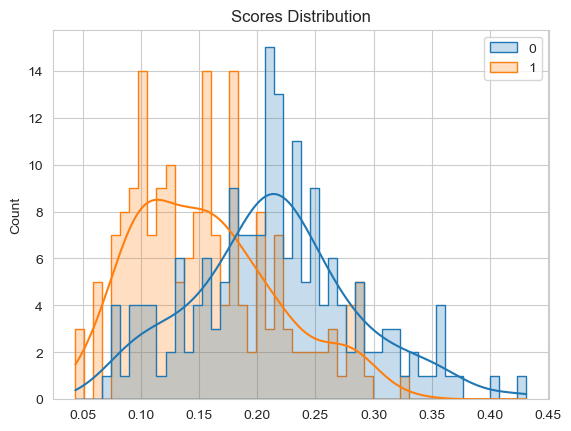

In [88]:
sns.histplot(
    x=global_best_scores,
    hue=trh_labels,
    bins=50,
    kde=True,
    element="step"
)
plt.title(f"Scores Distribution")
plt.show()

<h4>Testing</h4>

In [45]:
class Eliminator:
    def __init__(self, model_type, latent_size, top_k_percent=0.05, threshold=0.5, criterion_type="mse"):
        self.model = ArtifactAutoencoder(latent_size).to(device)
        self.model.load_state_dict(torch.load(f"models/artifact_eliminator_{model_type}_{latent_size}.pth", map_location=device))
        self.model.eval()

        self.transform = val_transforms
        self.threshold = threshold
        self.top_k_percent = top_k_percent

        if criterion_type == "vgg":
            self.criterion = PerceptualLoss(reduction='none').to(device)
        elif criterion_type == "mse":
            self.criterion = nn.MSELoss(reduction='none').to(device)

    @torch.no_grad()
    def predict_loader(self, loader):
        all_preds = []
        all_labels = []

        for inputs, labels in tqdm(loader, desc="Inference", leave=False):
            inputs = inputs.to(device)
            outputs = self.model(inputs)

            pixel_losses = self.criterion(outputs, inputs)

            batch_size = pixel_losses.size(0)
            flat_losses = pixel_losses.view(batch_size, -1)
            k_pixels = int(flat_losses.size(1) * self.top_k_percent)

            topk_values, _ = torch.topk(flat_losses, k_pixels, dim=1)
            image_scores = topk_values.mean(dim=1).cpu().numpy()

            preds = (image_scores <= self.threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels)

        return np.array(all_preds), np.array(all_labels)

    @torch.no_grad()
    def predict_image(self, image_path):
        input_data = Image.open(image_path).convert("RGB")
        input_data = self.transform(input_data)

        if input_data.dim() == 3:
            input_data = input_data.unsqueeze(0)

        input_data = input_data.to(device)
        output_data = self.model(input_data)

        pixel_error = self.criterion(input_data, output_data)

        flat_losses = pixel_error.view(1, -1)
        k_pixels = int(flat_losses.size(1) * self.top_k_percent)
        topk_values, _ = torch.topk(flat_losses, k_pixels, dim=1)

        image_score = topk_values.mean().item()

        img_orig = np.clip(input_data.squeeze(0).cpu().numpy().transpose((1, 2, 0)), 0, 1)
        img_recon = np.clip(output_data.squeeze(0).cpu().numpy().transpose((1, 2, 0)), 0, 1)
        heatmap = pixel_error[0].mean(dim=0).cpu().numpy()

        fig, axes = plt.subplots(1, 4, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1, 1, 0.05]})

        pred_label = 1 if image_score <= self.threshold else 0

        axes[0].imshow(img_orig)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(img_recon)
        axes[1].set_title("Reconstructed")
        axes[1].axis("off")

        hm = axes[2].imshow(heatmap, cmap='hot')
        axes[2].set_title("Error Map")
        axes[2].axis("off")

        fig.colorbar(hm, cax=axes[3])

        plt.tight_layout()
        plt.show()

        return pred_label, image_score, self.threshold

In [46]:
test_dir = 'data/test/'

all_test_files = os.listdir(test_dir)
all_test_labels = [int(f.split('_')[-1].split('.')[0]) for f in all_test_files]

test_set = ArtifactDataset(test_dir, all_test_files, all_test_labels, val_transforms)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

In [109]:
latent_size = 128
model_type = "hybrid"
criterion_type = "mse"
top_k_percent = 0.07
threshold = 0.1838

eliminator = Eliminator(model_type, latent_size, top_k_percent, threshold, criterion_type)

C:\Users\ACER\AppData\Local\Temp\ipykernel_10760\1567996611.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(f"models/artifact_elimi

In [51]:
test_preds, test_labels_true = eliminator.predict_loader(test_loader)
test_f1_micro = f1_score(test_labels_true, test_preds, average='micro')
test_f1_macro = f1_score(test_labels_true, test_preds, average='macro')
test_f1_weighted = f1_score(test_labels_true, test_preds, average='weighted')

print(f"Test Micro F1: {test_f1_micro:.4f}")
print(f"Test Macro F1: {test_f1_macro:.4f}")
print(f"Test Weighted F1: {test_f1_weighted:.4f}")
print("Confusion Matrix:\n", confusion_matrix(test_labels_true, test_preds))

Inference:   0%|          | 0/4 [00:00<?, ?it/s]

Test Micro F1: 0.6850
Test Macro F1: 0.5651
Test Weighted F1: 0.7478
Confusion Matrix:
 [[ 16   4]
 [ 59 121]]


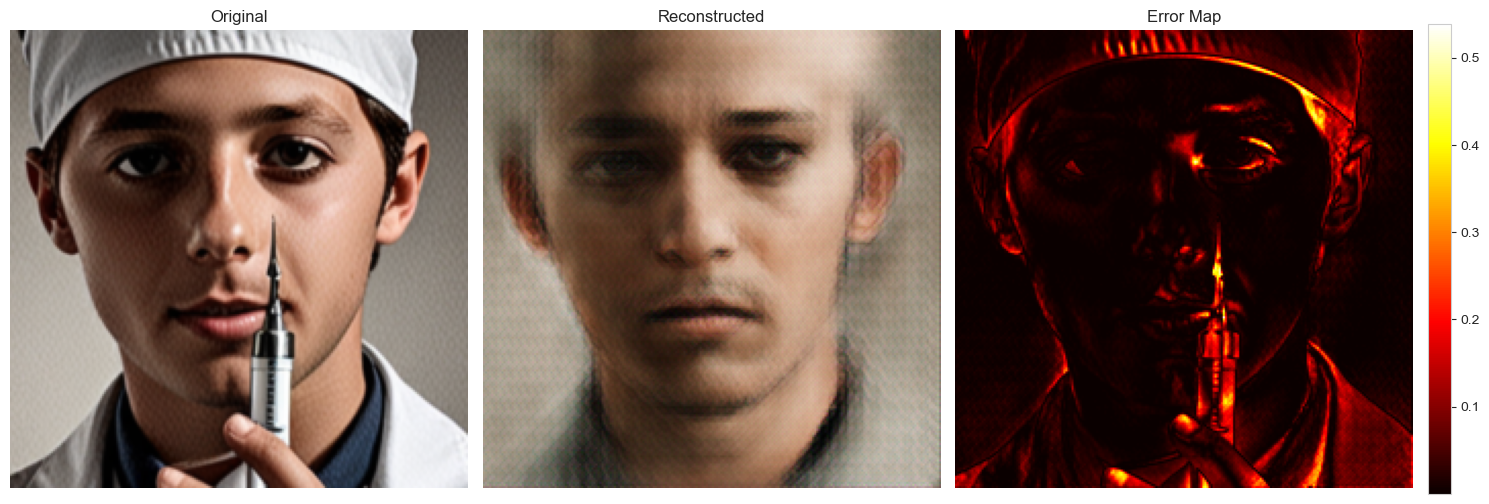

Real label:      0
Predicted label: 0
Score:           0.1846
Threshold:       0.1838


In [117]:
input_id = int(input("Enter Test ID: "))
test_id = input_id - 1

img_name = test_set.file_names[test_id]
img_path = os.path.join(test_dir, img_name)
real_label = test_set.labels[test_id]

pred_label, score, threshold = eliminator.predict_image(img_path)

print(f"Real label:      {real_label}")
print(f"Predicted label: {pred_label}")
print(f"Score:           {score:.4f}")
print(f"Threshold:       {threshold:.4f}")

<h4>Memory cleaning</h4>

In [22]:
def clear_memory(*var_names):
    for var in var_names:
        if var in globals():
            del globals()[var]

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [23]:
clear_memory('model', 'optimizer', 'eliminator')